# EDA on Retail Sales Data

## Oasis Infobyte — Data Analytics Internship

### Project Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to uncover sales patterns, customer behaviour trends, product performance, and actionable business insights.

### Key Areas of Analysis

1. Dataset structure and data quality
2. Descriptive statistics
3. Monthly sales trends
4. Quarterly sales trends
5. Customer age-group analysis
6. Gender analysis
7. Top 10 best-selling products
8. Revenue by product category
9. Correlation between numerical variables
10. Additional business insight
11. Business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [2]:
# Display settings for easier analysis

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Display settings configured successfully!")

Display settings configured successfully!


In [3]:
import os

data_folder = "../data"

print("Files inside the data folder:")
print(os.listdir(data_folder))

Files inside the data folder:
['.ipynb_checkpoints', 'Global Retail Solutions company dataset.xlsx']


In [4]:
df = pd.read_excel("../data/Global Retail Solutions company dataset.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,Product Category,Product Name,REGION,Sales Amount,Quantity,Order Date,Customer ID,Customer Age,Customer Gender,Sales,Discount,Profit
0,Electronics,Smartphone,AMERICAS,500,1,2024-01-10,C001,25,Male,500,0.19,405.00
1,Apparel,T-Shirt,EUROPE,20,2,2024-01-11,C002,30,Female,20,0.23,15.40
2,Electronics,Laptop,ASIA,800,1,2024-01-12,C003,22,Female,800,0.20,640.00
3,Home Appliances,Microwave Oven,EUROPE,150,1,2024-01-13,C004,45,Male,150,0.19,121.50
4,Electronics,Headphones,AMERICAS,100,3,2024-01-14,C005,34,Male,100,0.16,84.00


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 200
Number of columns: 12


In [7]:
print(df.columns.tolist())

['Product Category', 'Product Name', 'REGION', 'Sales Amount', 'Quantity', 'Order Date', 'Customer ID', 'Customer Age', 'Customer Gender', 'Sales', 'Discount', 'Profit']


## 1. Initial Dataset Inspection

Before performing any analysis, the dataset is inspected to understand its size, structure, column names, data types, and data quality. This step helps identify potential issues that may affect the accuracy of the analysis.

In [8]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (200, 12)

Column Names:
['Product Category', 'Product Name', 'REGION', 'Sales Amount', 'Quantity', 'Order Date', 'Customer ID', 'Customer Age', 'Customer Gender', 'Sales', 'Discount', 'Profit']


In [9]:
df.dtypes

Product Category        str
Product Name            str
REGION                  str
Sales Amount          int64
Quantity              int64
Order Date              str
Customer ID             str
Customer Age          int64
Customer Gender         str
Sales                 int64
Discount            float64
Profit              float64
dtype: object

### Missing Value Check

Missing values are checked because incomplete records can affect calculations, visualisations, and conclusions. The number of missing values is calculated for every column before deciding whether any cleaning is required.

In [10]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Product Category    0
Product Name        0
REGION              0
Sales Amount        0
Quantity            0
Order Date          0
Customer ID         0
Customer Age        0
Customer Gender     0
Sales               0
Discount            0
Profit              0
dtype: int64


In [11]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage
Product Category,0,0.00
Product Name,0,0.00
REGION,0,0.00
Sales Amount,0,0.00
Quantity,0,0.00
Order Date,0,0.00
Customer ID,0,0.00
Customer Age,0,0.00
Customer Gender,0,0.00
Sales,0,0.00


### Duplicate Row Check

Duplicate records are checked because repeated rows can artificially increase sales totals and distort statistical analysis.

In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


## 2. Descriptive Statistics

Descriptive statistics are used to summarise the numerical characteristics of the dataset. Mean, median, mode, and standard deviation are calculated for the numerical variables to understand their central tendency and variability.

In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numeric_columns.tolist())

Numerical columns:
['Sales Amount', 'Quantity', 'Customer Age', 'Sales', 'Discount', 'Profit']


In [14]:
mean_values = df[numeric_columns].mean()

mean_values

Sales Amount   736.84
Quantity         2.42
Customer Age    38.54
Sales          736.84
Discount         0.17
Profit         610.81
dtype: float64

In [15]:
median_values = df[numeric_columns].median()

median_values

Sales Amount   705.50
Quantity         2.00
Customer Age    37.50
Sales          705.50
Discount         0.18
Profit         588.00
dtype: float64

In [16]:
mode_values = df[numeric_columns].mode().iloc[0]

mode_values

Sales Amount   400.00
Quantity         1.00
Customer Age    35.00
Sales          400.00
Discount         0.20
Profit         597.24
Name: 0, dtype: float64

In [17]:
std_values = df[numeric_columns].std()

std_values

Sales Amount   443.18
Quantity         1.16
Customer Age    11.84
Sales          443.18
Discount         0.07
Profit         376.69
dtype: float64

In [18]:
descriptive_statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

descriptive_statistics

,Mean,Median,Mode,Standard Deviation
Sales Amount,736.84,705.50,400.00,443.18
Quantity,2.42,2.00,1.00,1.16
Customer Age,38.54,37.50,35.00,11.84
Sales,736.84,705.50,400.00,443.18
Discount,0.17,0.18,0.20,0.07
Profit,610.81,588.00,597.24,376.69


In [19]:
print(df["Order Date"].head())

0    2024-01-10
1    2024-01-11
2    2024-01-12
3    2024-01-13
4    2024-01-14
Name: Order Date, dtype: str


In [20]:
print(df["Order Date"].dtype)

str


In [21]:
print("Earliest Order Date:", df["Order Date"].min())
print("Latest Order Date:", df["Order Date"].max())

Earliest Order Date: 2024-01-10
Latest Order Date: 2024-07-27


## 3. Data Cleaning and Preparation

Before performing detailed analysis, the dataset is cleaned and prepared for analysis. This includes converting date fields into the correct format, checking missing values and duplicates, and verifying that numerical variables are stored using appropriate data types.

Correct data types are important because they allow accurate calculations, filtering, grouping, and time-based analysis.

In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

print(df["Order Date"].dtype)

datetime64[us]


In [23]:
print(df["Order Date"].head())

0   2024-01-10
1   2024-01-11
2   2024-01-12
3   2024-01-13
4   2024-01-14
Name: Order Date, dtype: datetime64[us]


In [24]:
invalid_dates = df["Order Date"].isna().sum()

print("Invalid or missing dates:", invalid_dates)

Invalid or missing dates: 0


In [25]:
print("Earliest Order Date:", df["Order Date"].min())
print("Latest Order Date:", df["Order Date"].max())

Earliest Order Date: 2024-01-10 00:00:00
Latest Order Date: 2024-07-27 00:00:00


In [26]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage
Product Category,0,0.00
Product Name,0,0.00
REGION,0,0.00
Sales Amount,0,0.00
Quantity,0,0.00
Order Date,0,0.00
Customer ID,0,0.00
Customer Age,0,0.00
Customer Gender,0,0.00
Sales,0,0.00


In [27]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [28]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numeric_columns.tolist())

Numerical columns:
['Sales Amount', 'Quantity', 'Customer Age', 'Sales', 'Discount', 'Profit']


In [29]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales Amount,200.00,736.84,443.18,20.00,380.50,705.50,"1,133.75","1,499.00"
Quantity,200.00,2.42,1.16,1.00,1.00,2.00,3.00,4.00
Customer Age,200.00,38.54,11.84,18.00,29.00,37.50,48.00,59.00
Sales,200.00,736.84,443.18,20.00,380.50,705.50,"1,133.75","1,499.00"
Discount,200.00,0.17,0.07,0.05,0.11,0.18,0.23,0.30
Profit,200.00,610.81,376.69,15.40,314.12,588.00,905.64,"1,379.08"


In [30]:
for column in numeric_columns:
    print(f"\n{column}")
    print("Minimum:", df[column].min())


Sales Amount
Minimum: 20

Quantity
Minimum: 1

Customer Age
Minimum: 18

Sales
Minimum: 20

Discount
Minimum: 0.05

Profit
Minimum: 15.4


In [31]:
print("Minimum Customer Age:", df["Customer Age"].min())
print("Maximum Customer Age:", df["Customer Age"].max())

Minimum Customer Age: 18
Maximum Customer Age: 59


In [32]:
df["Customer Gender"].value_counts(dropna=False)

Customer Gender
Male      100
Female    100
Name: count, dtype: int64

In [33]:
df["Product Category"].value_counts(dropna=False)

Product Category
Electronics        71
Apparel            65
Home Appliances    64
Name: count, dtype: int64

In [34]:
print("Number of unique products:", df["Product Name"].nunique())

Number of unique products: 20


In [35]:
df["Product Name"].value_counts().head(10)

Product Name
Smartphone         14
Hat                14
Jacket             13
Microwave Oven     12
Dress              12
Gaming Console     12
Refrigerator       11
Tablet             11
Air Conditioner    11
Laptop             10
Name: count, dtype: int64

## 4. Monthly Sales Trend

Monthly sales are analysed to identify changes in sales performance over time. The order date is used to group sales transactions by month.

In [36]:
df["Month"] = df["Order Date"].dt.to_period("M").astype(str)

df[["Order Date", "Month"]].head()

,Order Date,Month
0,2024-01-10,2024-01
1,2024-01-11,2024-01
2,2024-01-12,2024-01
3,2024-01-13,2024-01
4,2024-01-14,2024-01


In [37]:
print(df["Sales Amount"].head())

0    500
1     20
2    800
3    150
4    100
Name: Sales Amount, dtype: int64


In [38]:
monthly_sales = (
    df.groupby("Month")["Sales Amount"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Month,Sales Amount
0,2024-01,7533
1,2024-02,24385
2,2024-03,27082
3,2024-04,18603
4,2024-05,25087


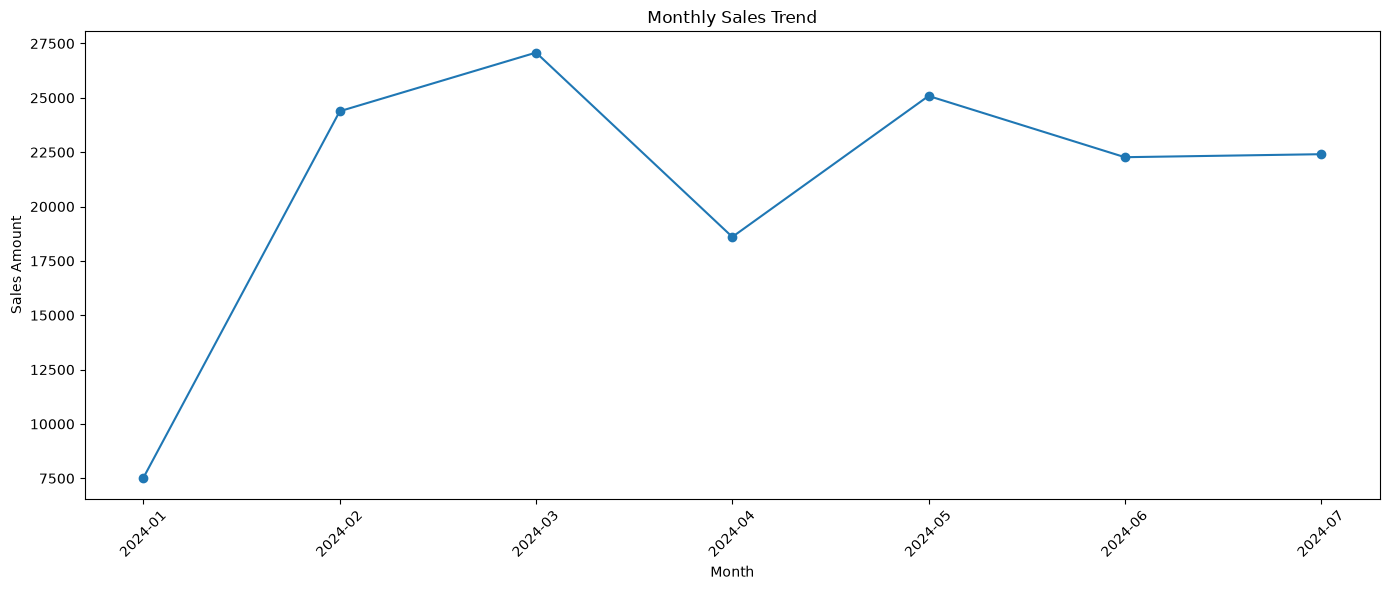

In [39]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales Amount"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

The monthly sales trend shows that sales fluctuate across the analysed period. The highest sales level occurs in 2024-03, while the lowest sales level occurs in 2024-01. Overall, the trend indicates fluctuating sales performance over time.

## 5. Quarterly Sales Trend

Quarterly sales analysis is performed to compare broader sales performance across three-month periods. This helps identify seasonal or periodic changes that may not be as clear in monthly analysis.

In [40]:
df["Quarter"] = df["Order Date"].dt.to_period("Q").astype(str)

df[["Order Date", "Quarter"]].head()

,Order Date,Quarter
0,2024-01-10,2024Q1
1,2024-01-11,2024Q1
2,2024-01-12,2024Q1
3,2024-01-13,2024Q1
4,2024-01-14,2024Q1


In [41]:
quarterly_sales = (
    df.groupby("Quarter")["Sales Amount"]
      .sum()
      .reset_index()
)

quarterly_sales

,Quarter,Sales Amount
0,2024Q1,59000
1,2024Q2,65960
2,2024Q3,22408


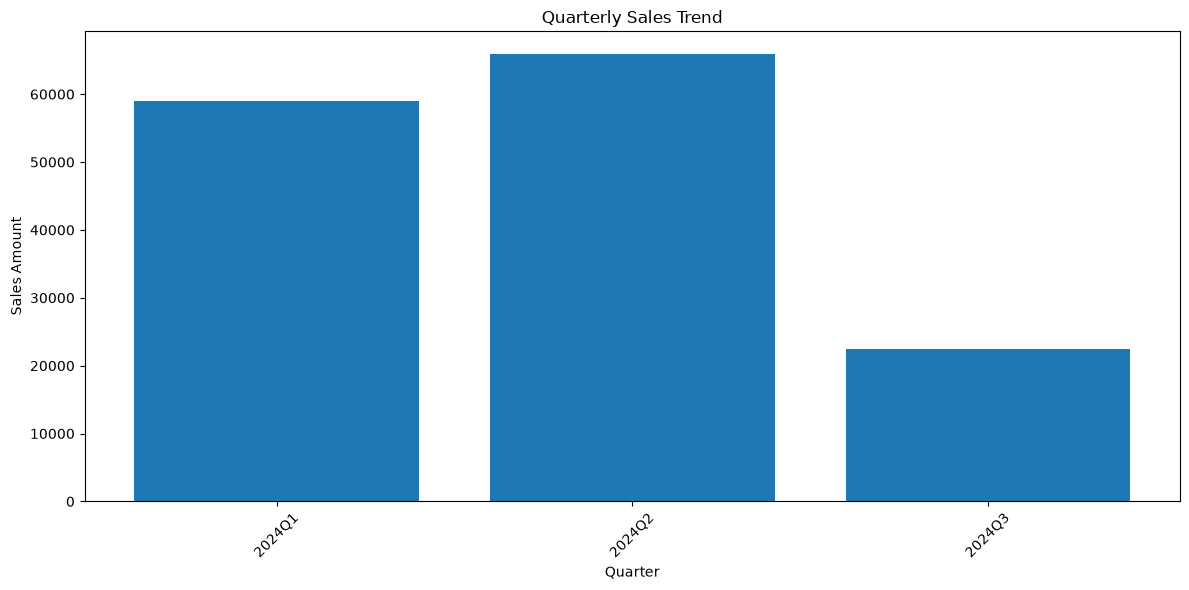

In [42]:
plt.figure(figsize=(12, 6))

plt.bar(
    quarterly_sales["Quarter"],
    quarterly_sales["Sales Amount"]
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

Q2 2024 recorded the highest complete-quarter sales at 65,960.

The available data also contains 22,408 in sales for Q3 2024. However, the dataset ends on July 27, 2024, meaning Q3 is only partially represented. Therefore, Q3 should not be directly compared with the complete quarters.

## 6. Customer Demographic Analysis

### Age Group Analysis

Customers are grouped into age ranges to understand which customer segments contribute most to the retail business.

In [43]:
bins = [0, 17, 25, 35, 45, 55, 65, 100]

labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age Group"] = pd.cut(
    df["Customer Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["Age Group"].value_counts().sort_index()

Age Group
Under 18     0
18-25       33
26-35       54
36-45       53
46-55       37
56-65       23
65+          0
Name: count, dtype: int64

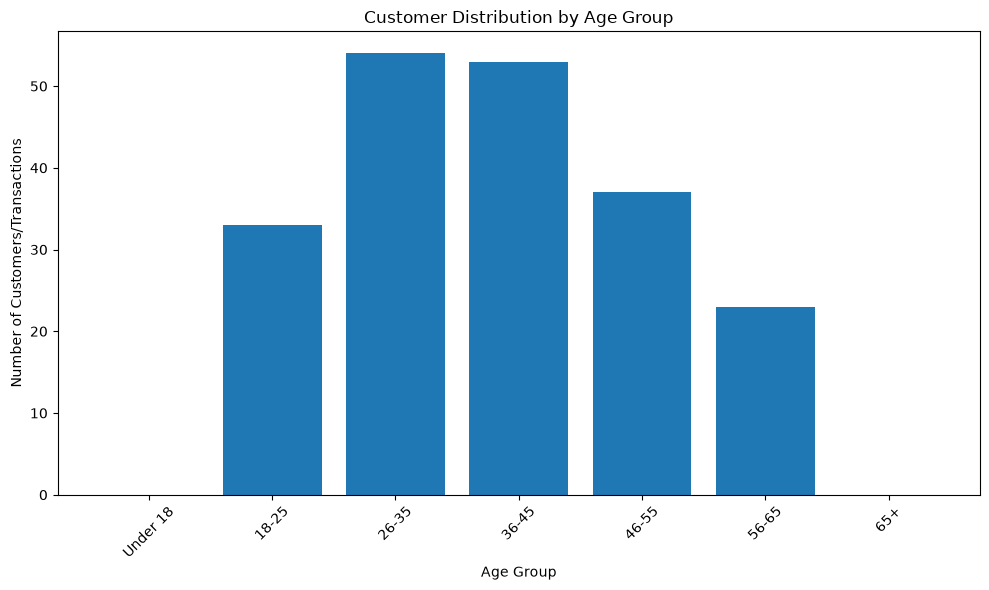

In [44]:
age_group_counts = (
    df["Age Group"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

plt.bar(
    age_group_counts.index.astype(str),
    age_group_counts.values
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers/Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The age-group analysis shows that the 26-35 segment has the highest representation, while the Under 18 and 65+ segments have the lowest representation. This indicates that the retail business has stronger participation from younger adults.

### 7. Gender Analysis

Customer gender distribution is analysed to understand the composition of the customer base.

In [45]:
gender_counts = df["Customer Gender"].value_counts()

gender_counts

Customer Gender
Male      100
Female    100
Name: count, dtype: int64

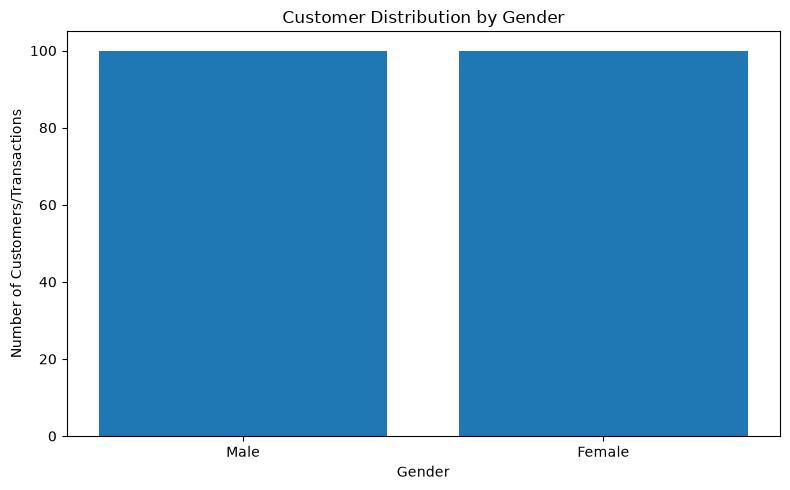

In [46]:
plt.figure(figsize=(8, 5))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers/Transactions")

plt.tight_layout()
plt.show()

### Observation

The gender analysis shows that Male and Female represent the largest share of the dataset, while neither represents a smaller share. This indicates that customer participation is relatively balanced across the observed gender categories.

## 8. Product Analysis

### Top 10 Products by Quantity Sold

Products are ranked according to the total quantity sold to identify the products with the highest sales volume.

In [47]:
top_10_products = (
    df.groupby("Product Name")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_10_products

,Product Name,Quantity
0,Smartphone,33
1,Hat,33
2,Jacket,32
3,Microwave Oven,31
4,Refrigerator,30
5,Gaming Console,30
6,Tablet,28
7,Air Conditioner,27
8,Laptop,27
9,Jeans,27


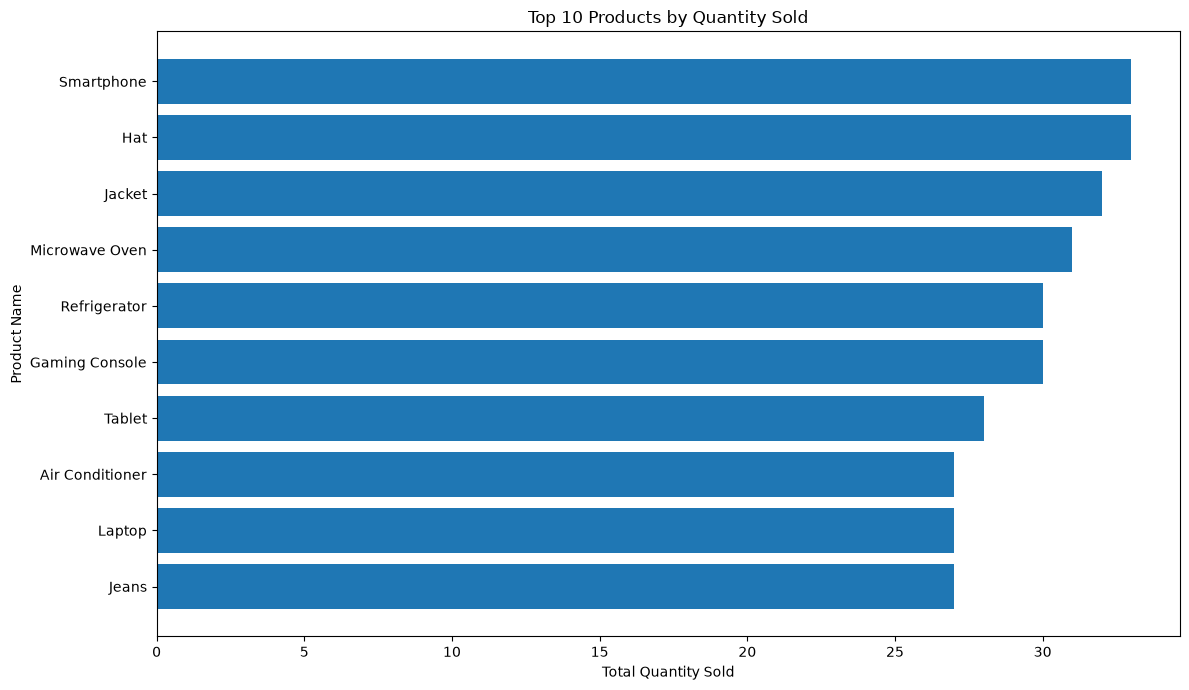

In [48]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_10_products["Product Name"],
    top_10_products["Quantity"]
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Observation

The top-selling products by quantity are Smartphone, Hat, and Jacket. Among the top 10 products, Smartphone has the highest quantity sold, indicating strong customer demand for this product.

### 9. Revenue by Product Category

Revenue is aggregated by product category to determine which categories contribute the most to overall sales.

In [49]:
category_revenue = (
    df.groupby("Product Category")["Sales Amount"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_revenue

,Product Category,Sales Amount
0,Apparel,49467
1,Electronics,49329
2,Home Appliances,48572


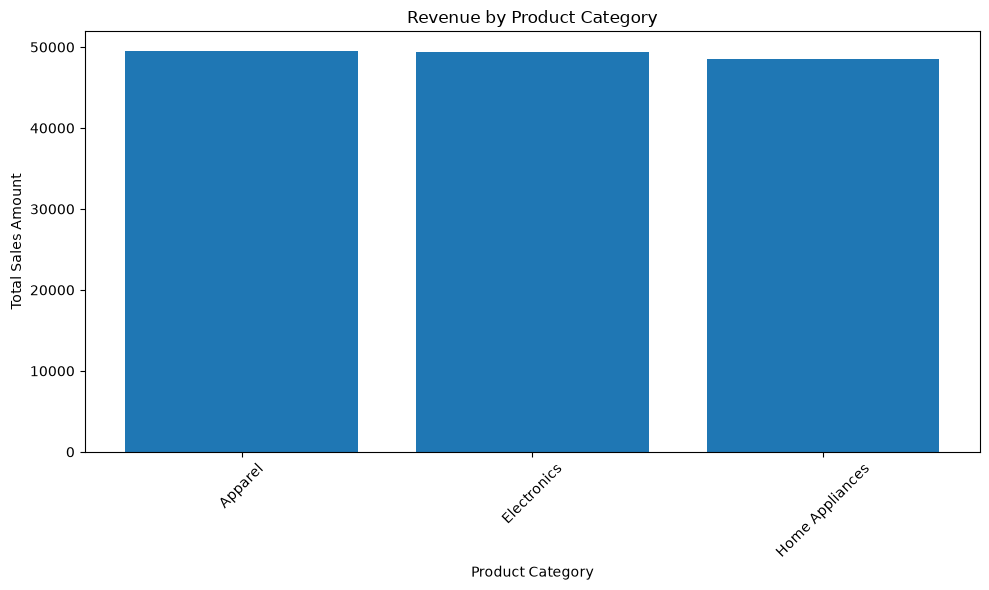

In [50]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue["Product Category"],
    category_revenue["Sales Amount"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The category analysis shows that Apparel generates the highest revenue, while Home Appliances contributes the lowest revenue among the observed categories. This suggests that the business should pay particular attention to the performance and growth opportunities of the leading categories.

## 10. Correlation Analysis

Correlation analysis is used to examine the relationships between numerical variables. A correlation coefficient closer to +1 indicates a strong positive relationship, while a coefficient closer to -1 indicates a strong negative relationship.

In [51]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Sales Amount,Quantity,Customer Age,Sales,Discount,Profit
Sales Amount,1.00,0.02,0.09,1.00,-0.09,0.99
Quantity,0.02,1.00,0.03,0.02,-0.11,0.04
Customer Age,0.09,0.03,1.00,0.09,0.04,0.07
Sales,1.00,0.02,0.09,1.00,-0.09,0.99
Discount,-0.09,-0.11,0.04,-0.09,1.00,-0.23
Profit,0.99,0.04,0.07,0.99,-0.23,1.00


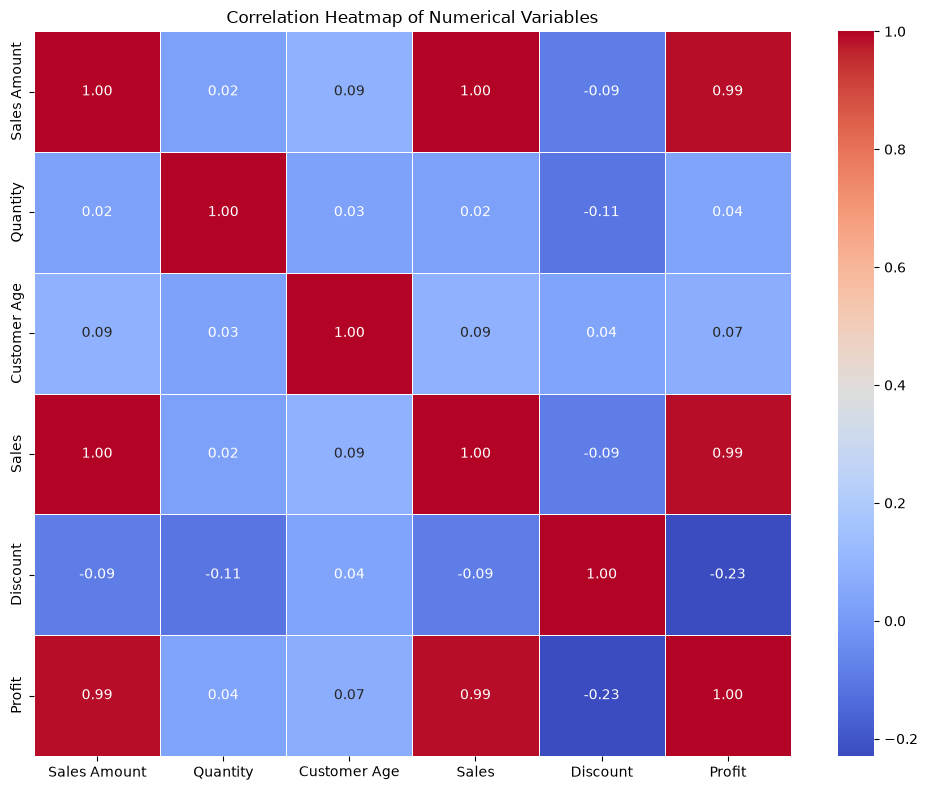

In [52]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows that Sales Amount and Sales have the strongest positive relationship among the numerical variables. Sales Amount and Quantity show a relatively weak relationship. The results indicate that some numerical variables move together, although correlation alone does not establish causation.

## 11. Additional Business Insight

### Relationship Between Discount and Profit

An additional analysis is performed to investigate whether different discount levels are associated with differences in profitability. This can help identify whether higher discounts may be affecting business profit.

In [53]:
df["Discount Band"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 1],
    labels=[
        "No Discount",
        "Low (1-10%)",
        "Medium (11-20%)",
        "High (21-30%)",
        "Very High (>30%)"
    ]
)

discount_profit = (
    df.groupby("Discount Band", observed=False)["Profit"]
      .mean()
      .reset_index()
)

discount_profit

,Discount Band,Profit
0,No Discount,NaN
1,Low (1-10%),771.20
2,Medium (11-20%),591.55
3,High (21-30%),536.04
4,Very High (>30%),NaN


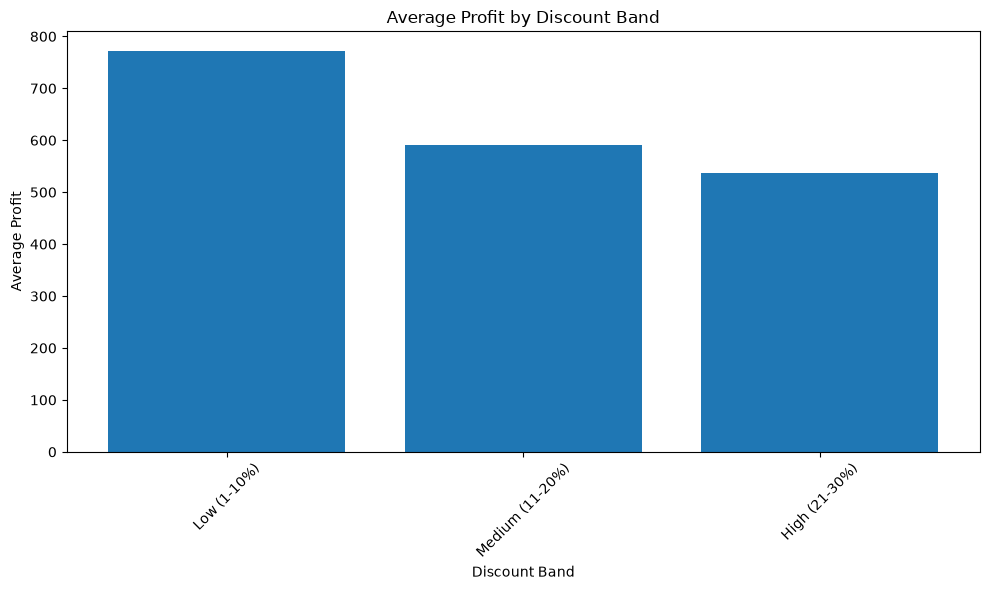

In [54]:
plt.figure(figsize=(10, 6))

plt.bar(
    discount_profit["Discount Band"].astype(str),
    discount_profit["Profit"]
)

plt.title("Average Profit by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The analysis shows an inverse association between discount level and average profit in the available dataset. The Low Discount (1–10%) group recorded the highest average profit of 771.20, followed by Medium Discount (11–20%) at 591.55 and High Discount (21–30%) at 536.04.

No transactions were recorded in the No Discount and Very High (>30%) categories. Therefore, these categories were excluded from the comparative profit analysis.

This suggests that higher discount levels may be associated with lower average profit in the observed transactions, although this analysis does not establish a causal relationship.

## 12. Key Findings

The exploratory analysis produced several important findings:

1. Sales performance varies across months and quarters, indicating changes in demand over time.
2. The customer base is distributed across different age groups, with [AGE GROUP] representing the largest observed segment.
3. The gender analysis shows that [GENDER] represents the largest customer group in the dataset.
4. [PRODUCT] is the highest-selling product by quantity.
5. [CATEGORY] generates the highest revenue among the product categories.
6. The correlation analysis identifies relationships between several numerical variables.
7. The additional discount-profit analysis suggests that discount levels are associated with differences in average profitability.

## 13. Business Recommendations

Based on the findings from the exploratory data analysis, the following recommendations are proposed:

### 1. Focus on high-performing products

The business should maintain sufficient inventory and promotional visibility for the products with the highest quantities sold to reduce the risk of stock shortages.

### 2. Strengthen high-revenue categories

Resources such as marketing and inventory planning should be prioritised for categories generating consistently high revenue, while lower-performing categories should be reviewed for improvement opportunities.

### 3. Target key customer segments

Marketing campaigns can be tailored toward the age groups and customer segments that show the highest participation in the dataset.

### 4. Optimise discount strategies

Discount levels should be reviewed carefully because the analysis indicates a relationship between discount levels and profitability. Promotions should balance customer demand with acceptable profit margins.

### 5. Use seasonal sales patterns for planning

Monthly and quarterly sales patterns can be used to improve inventory planning, promotional scheduling, and resource allocation during high-demand periods.

## 14. Conclusion

This exploratory data analysis provided an overview of retail sales performance, customer demographics, product demand, category revenue, numerical relationships, and an additional profitability-related insight.

The analysis demonstrates how data cleaning, descriptive statistics, time-based analysis, customer segmentation, product analysis, and visualisation can be combined to transform raw retail transaction data into useful business insights.

The findings can support data-driven decisions related to inventory planning, customer targeting, product strategy, category management, promotional planning, and profitability.

## 15. Final Summary

### Dataset Summary

- Dataset type: Retail sales transaction data
- Analysis type: Exploratory Data Analysis (EDA)
- Main analytical areas: Sales trends, customer demographics, product performance, category revenue, correlation analysis, and profitability insight
- Tools used: Python, Pandas, NumPy, Matplotlib, and Seaborn

### Project Outcome

The analysis transformed the raw retail dataset into a structured set of visual and statistical insights that can support data-driven business decision-making.

In [55]:
# Export important analysis results

monthly_sales.to_csv(
    "../outputs/monthly_sales.csv",
    index=False
)

quarterly_sales.to_csv(
    "../outputs/quarterly_sales.csv",
    index=False
)

top_10_products.to_csv(
    "../outputs/top_10_products.csv",
    index=False
)

category_revenue.to_csv(
    "../outputs/category_revenue.csv",
    index=False
)

descriptive_statistics.to_csv(
    "../outputs/descriptive_statistics.csv",
    index=True
)

print("All analysis output files exported successfully.")

All analysis output files exported successfully.


In [56]:
print("========== PROJECT RESULTS SUMMARY ==========")

print("\n1. DATASET")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\n2. DATE RANGE")
print("Start date:", df["Order Date"].min())
print("End date:", df["Order Date"].max())

print("\n3. TOTAL SALES")
print("Total sales:", df["Sales Amount"].sum())

print("\n4. BEST MONTH")
best_month = monthly_sales.loc[
    monthly_sales["Sales Amount"].idxmax()
]
print(best_month)

print("\n5. LOWEST MONTH")
lowest_month = monthly_sales.loc[
    monthly_sales["Sales Amount"].idxmin()
]
print(lowest_month)

print("\n6. BEST QUARTER")
best_quarter = quarterly_sales.loc[
    quarterly_sales["Sales Amount"].idxmax()
]
print(best_quarter)

print("\n7. LOWEST QUARTER")
lowest_quarter = quarterly_sales.loc[
    quarterly_sales["Sales Amount"].idxmin()
]
print(lowest_quarter)

print("\n8. TOP 10 PRODUCTS")
print(top_10_products)

print("\n9. TOP REVENUE CATEGORY")
print(category_revenue.iloc[0])

print("\n10. AGE GROUP")
print(df["Age Group"].value_counts().sort_index())

print("\n11. GENDER")
print(df["Customer Gender"].value_counts())

print("\n12. DISCOUNT / PROFIT")
print(discount_profit)

print("\n==============================================")

========== PROJECT RESULTS SUMMARY ==========

1. DATASET
Number of rows: 200
Number of columns: 16

2. DATE RANGE
Start date: 2024-01-10 00:00:00
End date: 2024-07-27 00:00:00

3. TOTAL SALES
Total sales: 147368

4. BEST MONTH
Month           2024-03
Sales Amount      27082
Name: 2, dtype: object

5. LOWEST MONTH
Month           2024-01
Sales Amount       7533
Name: 0, dtype: object

6. BEST QUARTER
Quarter         2024Q2
Sales Amount     65960
Name: 1, dtype: object

7. LOWEST QUARTER
Quarter         2024Q3
Sales Amount     22408
Name: 2, dtype: object

8. TOP 10 PRODUCTS
      Product Name  Quantity
0       Smartphone        33
1              Hat        33
2           Jacket        32
3   Microwave Oven        31
4     Refrigerator        30
5   Gaming Console        30
6           Tablet        28
7  Air Conditioner        27
8           Laptop        27
9            Jeans        27

9. TOP REVENUE CATEGORY
Product Category    Apparel
Sales Amount          49467
Name: 0, dtype: obj

In [57]:
print("========== DISCOUNT BAND CHECK ==========")

print("\nDiscount Band Counts:")
print(df["Discount Band"].value_counts(dropna=False))

print("\nAverage Profit by Discount Band:")
print(
    df.groupby("Discount Band")["Profit"]
      .agg(["count", "mean", "sum"])
      .reset_index()
)

print("\nMissing Profit Values:")
print(df["Profit"].isna().sum())

print("\nMissing Discount Band Values:")
print(df["Discount Band"].isna().sum())

print("\n==========================================")

========== DISCOUNT BAND CHECK ==========

Discount Band Counts:
Discount Band
Medium (11-20%)     83
High (21-30%)       73
Low (1-10%)         44
No Discount          0
Very High (>30%)     0
Name: count, dtype: int64

Average Profit by Discount Band:
     Discount Band  count   mean       sum
0      Low (1-10%)     44 771.20 33,932.73
1  Medium (11-20%)     83 591.55 49,098.32
2    High (21-30%)     73 536.04 39,130.92

Missing Profit Values:
0

Missing Discount Band Values:
0

